# Ratio de l'indice de marchabilité entre deux cartes

Ce notebook lit deux GeoPackages contenant un attribut `walk_index`, apparie les entités des deux cartes, puis calcule pour chacune le ratio

$$\text{ratio} = \frac{\text{walk\_index}_A}{\text{walk\_index}_B}$$

Le résultat est affiché sur une carte et exporté en GeoPackage.

**Appariement des entités** (`JOIN_MODE`) :
- `"auto"` : utilise `KEY` si la colonne existe dans les deux cartes, sinon l'ordre des lignes si les géométries sont identiques, sinon une intersection spatiale ;
- `"key"` : jointure sur une colonne identifiant commune (`KEY`) ;
- `"position"` : même grille, même ordre de lignes ;
- `"spatial"` : intersection géométrique (`gpd.overlay`), utile si les deux maillages diffèrent.

## 1. Paramètres

In [16]:
from pathlib import Path

# --- Fichiers d'entrée ---
PATH_A  = Path("/Users/maximiliantrique/Documents/GitHub/projet_pieton_gg/Data/output/walk/GG/step-3_unweighted/step3_index.gpkg")   # numérateur
PATH_B  = Path("/Users/maximiliantrique/Documents/GitHub/projet_pieton_gg/Data/output/walk/GG/step-3_geo_weighted/step3_index.gpkg")   # dénominateur
LAYER_A = None                          # None = première couche du GPKG
LAYER_B = None
# --- Attribut et appariement ---
ATTR      = "walk_index"
KEY       = "id"        # colonne identifiant commune (utilisée si présente)
JOIN_MODE = "auto"      # "auto" | "key" | "position" | "spatial"

# --- Sortie ---
OUT_PATH  = Path("/Users/maximiliantrique/Documents/GitHub/projet_pieton_gg/Data/output/walk/GG/step_4")
OUT_LAYER = "walk_index_ratio"

# Mode "spatial" pour lignes/points : distance max d'association (unités du CRS, m en 2056)
MAX_DIST = 5

# Valeur minimale du dénominateur (évite les divisions par ~0)
EPS = 1e-9

## 2. Lecture des cartes

In [17]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

def read_layer(path, layer):
    if layer is None:
        layers = gpd.list_layers(path) if hasattr(gpd, "list_layers") else None
        if layers is not None and len(layers) > 1:
            print(f"{path.name} contient plusieurs couches : {list(layers['name'])} -> lecture de la première")
    return gpd.read_file(path, layer=layer)

gdf_a = read_layer(PATH_A, LAYER_A)
gdf_b = read_layer(PATH_B, LAYER_B)

for name, g in [("A", gdf_a), ("B", gdf_b)]:
    print(f"Carte {name}: {len(g)} entités | CRS = {g.crs} | géométrie = {g.geom_type.unique()}")
    assert ATTR in g.columns, f"L'attribut '{ATTR}' est absent de la carte {name}. Colonnes : {list(g.columns)}" 

Carte A: 732164 entités | CRS = EPSG:4326 | géométrie = ['LineString']
Carte B: 732164 entités | CRS = EPSG:4326 | géométrie = ['LineString']


## 3. Harmonisation des systèmes de coordonnées

In [18]:
if gdf_a.crs != gdf_b.crs:
    print(f"CRS différents -> reprojection de B de {gdf_b.crs} vers {gdf_a.crs}")
    gdf_b = gdf_b.to_crs(gdf_a.crs)
else:
    print("CRS identiques :", gdf_a.crs)

CRS identiques : EPSG:4326


## 4. Appariement des entités et calcul du ratio

In [19]:
def choose_mode():
    if JOIN_MODE != "auto":
        return JOIN_MODE
    if KEY and KEY in gdf_a.columns and KEY in gdf_b.columns:
        return "key"
    if len(gdf_a) == len(gdf_b) and gdf_a.geometry.reset_index(drop=True).geom_equals(
            gdf_b.geometry.reset_index(drop=True)).all():
        return "position"
    return "spatial"

mode = choose_mode()
print("Mode d'appariement :", mode)

a = gdf_a[[c for c in [KEY, ATTR, "geometry"] if c in gdf_a.columns]].rename(columns={ATTR: f"{ATTR}_A"})
b = gdf_b[[c for c in [KEY, ATTR, "geometry"] if c in gdf_b.columns]].rename(columns={ATTR: f"{ATTR}_B"})

if mode == "key":
    dup_a, dup_b = a[KEY].duplicated().sum(), b[KEY].duplicated().sum()
    if dup_a or dup_b:
        print(f"Attention : identifiants dupliqués (A: {dup_a}, B: {dup_b})")
    res = a.merge(b.drop(columns="geometry"), on=KEY, how="inner")
    print(f"{len(res)} entités appariées ({len(a) - len(res)} de A et {len(b) - len(res)} de B sans correspondance)")

elif mode == "position":
    res = a.reset_index(drop=True).copy()
    res[f"{ATTR}_B"] = b[f"{ATTR}_B"].reset_index(drop=True).values

elif mode == "spatial":
    a_ = a.drop(columns=[KEY], errors="ignore")
    b_ = b.drop(columns=[KEY], errors="ignore")
    is_poly = a_.geom_type.str.contains("Polygon").all() and b_.geom_type.str.contains("Polygon").all()
    if is_poly:
        res = gpd.overlay(a_, b_, how="intersection", keep_geom_type=True)
        print(f"{len(res)} morceaux issus de l'intersection")
    else:
        # Lignes ou points : l'intersection géométrique donne des points ou rien,
        # on associe donc chaque entité de A à l'entité de B la plus proche.
        res = gpd.sjoin_nearest(a_, b_, how="left", max_distance=MAX_DIST,
                                distance_col="dist_join").drop(columns="index_right")
        res = res[~res.index.duplicated(keep="first")]
        print(f"{res[f'{ATTR}_B'].notna().sum()} / {len(res)} entités de A associées à une entité de B (≤ {MAX_DIST} m)")
else:
    raise ValueError(f"JOIN_MODE inconnu : {JOIN_MODE}")

def to_num(sr):
    if sr.dtype == object:
        sr = sr.astype(str).str.replace(",", ".", regex=False)
    return pd.to_numeric(sr, errors="coerce")

va = to_num(res[f"{ATTR}_A"])
vb = to_num(res[f"{ATTR}_B"])
res["ratio"] = np.where(vb.abs() > EPS, va / vb, np.nan)

n_nan = res["ratio"].isna().sum()
print(f"Ratio calculé ; {n_nan} entités sans valeur (dénominateur nul ou valeur manquante)")
res["ratio"].describe()

Mode d'appariement : position
Ratio calculé ; 34810 entités sans valeur (dénominateur nul ou valeur manquante)


count    697354.000000
mean          1.181583
std           1.145418
min           0.000000
25%           0.869926
50%           1.087466
75%           1.282124
max         500.000000
Name: ratio, dtype: float64

## 5. Diagnostic

Si la carte paraît vide, regarde d'abord ici.

In [20]:
print("Entités dans le résultat :", len(res))
print("Types de géométrie        :", res.geom_type.value_counts().to_dict())
print("Valeurs A (non nulles)    :", va.notna().sum(), "| dtype d'origine :", gdf_a[ATTR].dtype)
print("Valeurs B (non nulles)    :", vb.notna().sum(), "| dtype d'origine :", gdf_b[ATTR].dtype)
print("Ratios valides            :", res['ratio'].notna().sum())
print("Part des ratios dans [0.95, 1.05] :", round(res['ratio'].between(0.95, 1.05).mean() * 100, 1), "%")
print("Identiques A == B         :", int((va == vb).sum()))
if len(res) == 0:
    print("-> Aucun appariement : vérifie KEY / JOIN_MODE.")
elif res['ratio'].notna().sum() == 0:
    print("-> Tous les ratios sont NaN : walk_index est peut-être du texte (virgule décimale ?) ou B vaut 0 partout.")
elif (va == vb).mean() > 0.9:
    print("-> A et B sont quasi identiques : les deux chemins pointent-ils vers le même fichier, ou KEY apparie-t-il mal ?")

Entités dans le résultat : 732164
Types de géométrie        : {'LineString': 732164}
Valeurs A (non nulles)    : 697356 | dtype d'origine : float64
Valeurs B (non nulles)    : 697356 | dtype d'origine : float64
Ratios valides            : 697354
Part des ratios dans [0.95, 1.05] : 10.6 %
Identiques A == B         : 241


## 6. Carte du ratio

La palette divergente est centrée sur 1 (jaune pâle) : bleu = A < B, rouge = A > B. Les bornes sont prises aux percentiles 2–98 % pour que quelques valeurs extrêmes n'écrasent pas la carte.

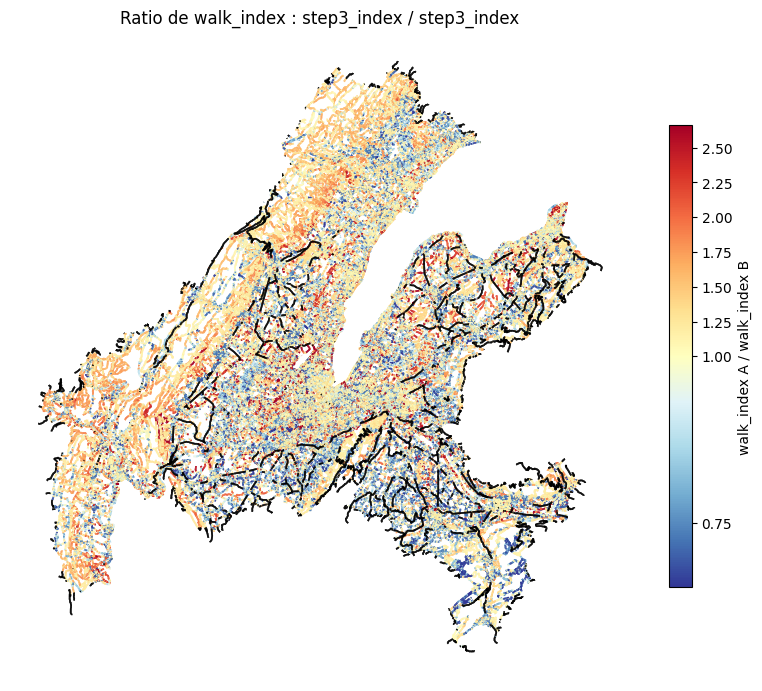

In [21]:
vals = res["ratio"].dropna()
assert len(vals) > 0, "Aucun ratio valide : voir le diagnostic ci-dessus."
vmin, vmax = np.nanpercentile(vals, [2, 98])
vmin, vmax = min(vmin, 0.999), max(vmax, 1.001)   # 1 doit être dans l'intervalle
norm = TwoSlopeNorm(vmin=vmin, vcenter=1.0, vmax=vmax)

gtype = res.geom_type.iloc[0]
style = {"linewidth": 1.2} if "Line" in gtype else {"markersize": 4} if "Point" in gtype else {"linewidth": 0}

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_facecolor("#f0f0f0")
res.plot(column="ratio", cmap="RdYlBu_r", norm=norm, legend=True, ax=ax, **style,
         missing_kwds={"color": "black", "label": "sans valeur"},
         legend_kwds={"label": f"{ATTR} A / {ATTR} B", "shrink": 0.6})
ax.set_title(f"Ratio de {ATTR} : {PATH_A.stem} / {PATH_B.stem}")
ax.set_axis_off()
plt.show()

### Distribution du ratio

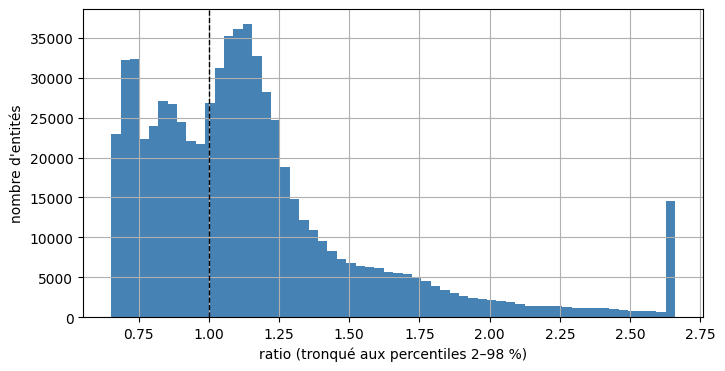

In [22]:
fig, ax = plt.subplots(figsize=(8, 4))
vals.clip(vmin, vmax).hist(bins=60, ax=ax, color="steelblue")
ax.axvline(1, color="k", ls="--", lw=1)
ax.set_xlabel("ratio (tronqué aux percentiles 2–98 %)")
ax.set_ylabel("nombre d'entités")
plt.show()

## 7. Export

In [23]:
# OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
# res.to_file(OUT_PATH, layer=OUT_LAYER, driver="GPKG")
# print(f"Écrit : {OUT_PATH} (couche '{OUT_LAYER}', {len(res)} entités)")